# 🌐 Redes de Computadores

`Sistemas/Redes` · **8º semestre · Engenharia da Computação** · `Python 3`

> **Camadas, encapsulamento, IP, sub-redes, roteamento, TCP/UDP e segurança.**

Redes de computadores na prática: endereçamento IP, cálculo de sub-redes CIDR, checksum, modelos de camadas e comparação TCP/UDP.


## 🖼️ Resultado visual

Este é o **cheat sheet** da matéria, gerado pelo código abaixo (a mesma lógica é reutilizada na célula de geração do PDF). As páginas são renderizadas automaticamente.


Redes_de_Computadores.pdf
Páginas: 1


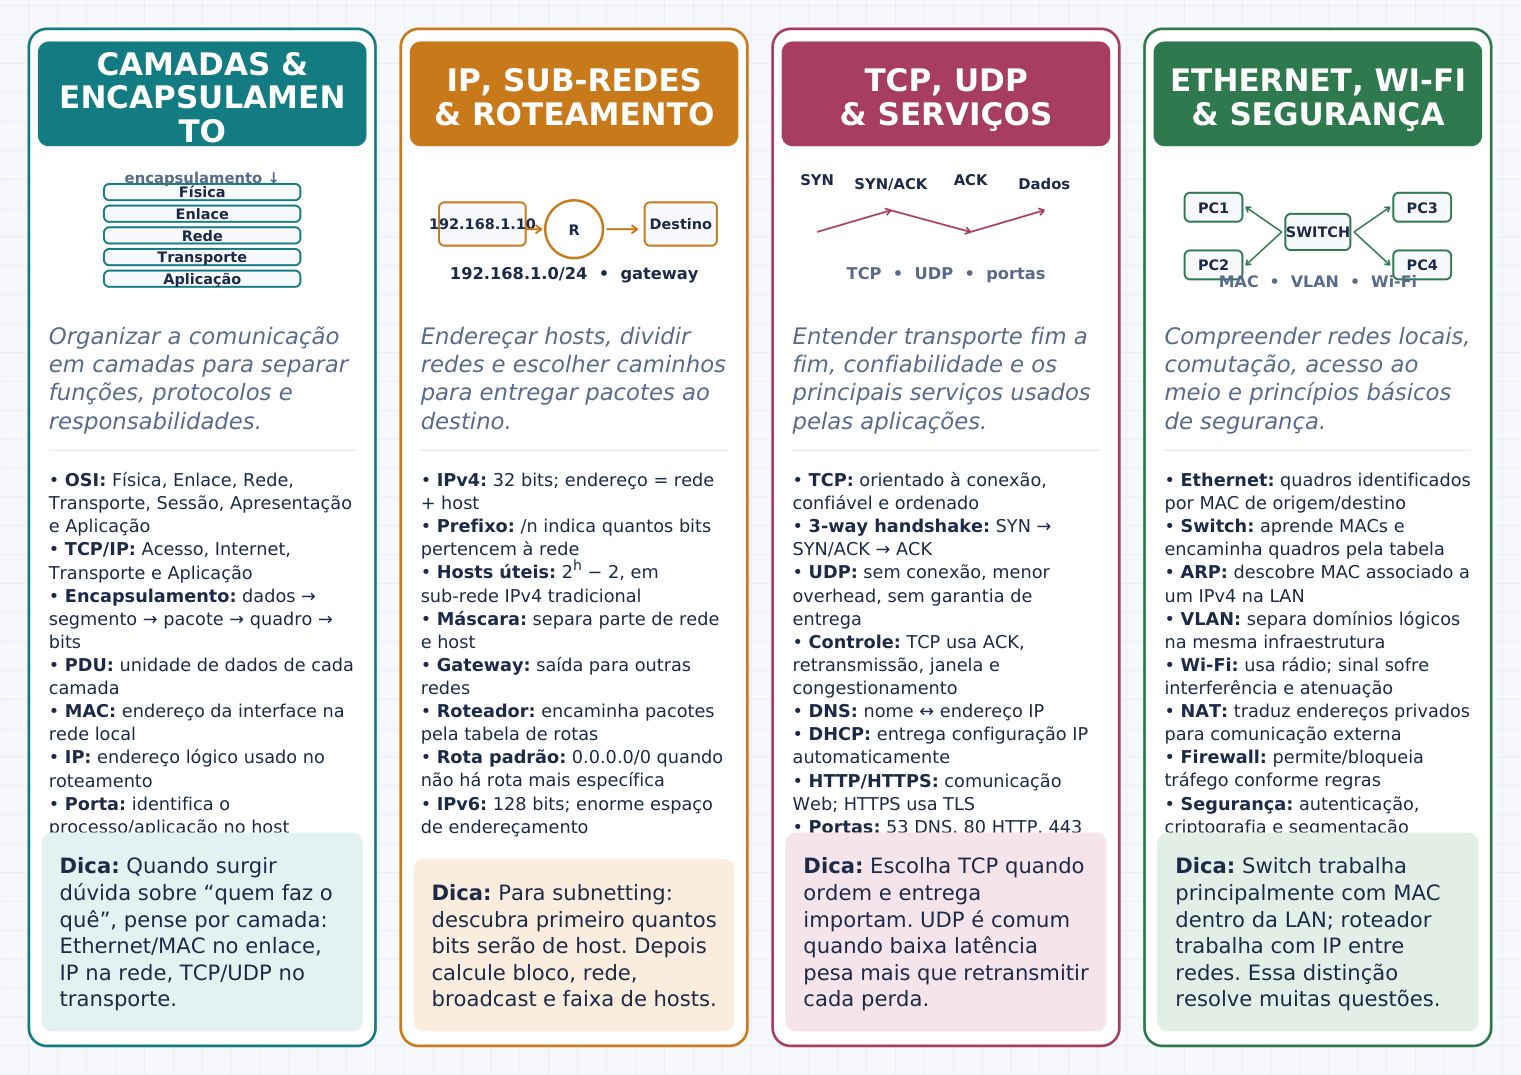

In [1]:
from pathlib import Path
import matplotlib as _mpl

def _dejavu_dir():
    _base = Path(_mpl.__file__).parent / "mpl-data" / "fonts" / "ttf"
    if (_base / "DejaVuSans.ttf").exists():
        return str(_base)
    for _p in [Path("/usr/share/fonts/truetype/dejavu"),
               Path("/System/Library/Fonts"),
               Path("/Library/Fonts"),
               Path("C:/Windows/Fonts")]:
        if (_p / "DejaVuSans.ttf").exists():
            return str(_p)
    raise RuntimeError("Fonte DejaVuSans nao encontrada; instale matplotlib ou a fonte DejaVu.")


# ===== código original adaptado =====
import math
from pathlib import Path
from reportlab.lib.colors import HexColor
from reportlab.lib.pagesizes import A4, landscape
from reportlab.lib.styles import ParagraphStyle
from reportlab.pdfbase import pdfmetrics
from reportlab.pdfbase.ttfonts import TTFont
from reportlab.pdfgen import canvas
from reportlab.platypus import Paragraph

OUT = Path('Redes_de_Computadores.pdf')
PAGE_W,PAGE_H=landscape(A4); MARGIN=16
FONT_DIR = Path(_dejavu_dir())
pdfmetrics.registerFont(TTFont('DVCond',str(FONT_DIR/'DejaVuSans.ttf')))
pdfmetrics.registerFont(TTFont('DVCond-Bold',str(FONT_DIR/'DejaVuSans-Bold.ttf')))
pdfmetrics.registerFont(TTFont('DVCond-Oblique',str(FONT_DIR/'DejaVuSans-Oblique.ttf')))
pdfmetrics.registerFontFamily('DVCond',normal='DVCond',bold='DVCond-Bold',italic='DVCond-Oblique',boldItalic='DVCond-Bold')
BG=HexColor('#F6F8FB'); GRID=HexColor('#E6EBF3'); INK=HexColor('#1C2B4A'); MUTED=HexColor('#5A6B8C'); WHITE=HexColor('#FFFFFF'); LINE=HexColor('#E7ECF4'); AXIS=HexColor('#D7DEEA')
TEAL,TEAL_T=HexColor('#147D82'),HexColor('#E3F2F1'); AMBER,AMBER_T=HexColor('#C97A1A'),HexColor('#FBEDDD'); BERRY,BERRY_T=HexColor('#A83E63'),HexColor('#F6E4EB'); GREEN,GREEN_T=HexColor('#2F7A4F'),HexColor('#E2F0E7')
CARDS=[
{'title':'CAMADAS &amp;<br/>ENCAPSULAMENTO','color':TEAL,'tint':TEAL_T,'kind':'camadas','idea':'Organizar a comunicação em camadas para separar funções, protocolos e responsabilidades.','formulas':['<b>OSI:</b> Física, Enlace, Rede, Transporte, Sessão, Apresentação e Aplicação','<b>TCP/IP:</b> Acesso, Internet, Transporte e Aplicação','<b>Encapsulamento:</b> dados → segmento → pacote → quadro → bits','<b>PDU:</b> unidade de dados de cada camada','<b>MAC:</b> endereço da interface na rede local','<b>IP:</b> endereço lógico usado no roteamento','<b>Porta:</b> identifica o processo/aplicação no host','<b>Protocolos:</b> regras de formato, ordem e tratamento de mensagens'],'tip':'Quando surgir dúvida sobre “quem faz o quê”, pense por camada: Ethernet/MAC no enlace, IP na rede, TCP/UDP no transporte.'},
{'title':'IP, SUB-REDES<br/>&amp; ROTEAMENTO','color':AMBER,'tint':AMBER_T,'kind':'ip','idea':'Endereçar hosts, dividir redes e escolher caminhos para entregar pacotes ao destino.','formulas':['<b>IPv4:</b> 32 bits; endereço = rede + host','<b>Prefixo:</b> /n indica quantos bits pertencem à rede','<b>Hosts úteis:</b> 2<super>h</super> − 2, em sub-rede IPv4 tradicional','<b>Máscara:</b> separa parte de rede e host','<b>Gateway:</b> saída para outras redes','<b>Roteador:</b> encaminha pacotes pela tabela de rotas','<b>Rota padrão:</b> 0.0.0.0/0 quando não há rota mais específica','<b>IPv6:</b> 128 bits; enorme espaço de endereçamento'],'tip':'Para subnetting: descubra primeiro quantos bits serão de host. Depois calcule bloco, rede, broadcast e faixa de hosts.'},
{'title':'TCP, UDP<br/>&amp; SERVIÇOS','color':BERRY,'tint':BERRY_T,'kind':'transporte','idea':'Entender transporte fim a fim, confiabilidade e os principais serviços usados pelas aplicações.','formulas':['<b>TCP:</b> orientado à conexão, confiável e ordenado','<b>3-way handshake:</b> SYN → SYN/ACK → ACK','<b>UDP:</b> sem conexão, menor overhead, sem garantia de entrega','<b>Controle:</b> TCP usa ACK, retransmissão, janela e congestionamento','<b>DNS:</b> nome ↔ endereço IP','<b>DHCP:</b> entrega configuração IP automaticamente','<b>HTTP/HTTPS:</b> comunicação Web; HTTPS usa TLS','<b>Portas:</b> 53 DNS, 80 HTTP, 443 HTTPS, 22 SSH'],'tip':'Escolha TCP quando ordem e entrega importam. UDP é comum quando baixa latência pesa mais que retransmitir cada perda.'},
{'title':'ETHERNET, WI-FI<br/>&amp; SEGURANÇA','color':GREEN,'tint':GREEN_T,'kind':'lan','idea':'Compreender redes locais, comutação, acesso ao meio e princípios básicos de segurança.','formulas':['<b>Ethernet:</b> quadros identificados por MAC de origem/destino','<b>Switch:</b> aprende MACs e encaminha quadros pela tabela','<b>ARP:</b> descobre MAC associado a um IPv4 na LAN','<b>VLAN:</b> separa domínios lógicos na mesma infraestrutura','<b>Wi-Fi:</b> usa rádio; sinal sofre interferência e atenuação','<b>NAT:</b> traduz endereços privados para comunicação externa','<b>Firewall:</b> permite/bloqueia tráfego conforme regras','<b>Segurança:</b> autenticação, criptografia e segmentação'],'tip':'Switch trabalha principalmente com MAC dentro da LAN; roteador trabalha com IP entre redes. Essa distinção resolve muitas questões.'}
]
CARD_TOP=PAGE_H-16; CARD_BOTTOM=16; CARD_H=CARD_TOP-CARD_BOTTOM; GAP=14; CARD_W=(PAGE_W-2*MARGIN-3*GAP)/4
STYLE_TITLE=ParagraphStyle('title',fontName='DVCond-Bold',fontSize=17.2,leading=18.6,textColor=WHITE,alignment=1)
STYLE_IDEA=ParagraphStyle('idea',fontName='DVCond-Oblique',fontSize=12.6,leading=15.6,textColor=MUTED)
STYLE_TIP=ParagraphStyle('tip',fontName='DVCond',fontSize=11.7,leading=14.7,textColor=INK)

def arrow(c,x1,y1,x2,y2,color,width=1.1,head=4):
 c.setStrokeColor(color); c.setFillColor(color); c.setLineWidth(width); c.line(x1,y1,x2,y2); a=math.atan2(y2-y1,x2-x1)
 for d in (2.55,-2.55): c.line(x2,y2,x2+head*math.cos(a+d),y2+head*math.sin(a+d))

def box(c,x,y,w,h,color,label):
 c.setStrokeColor(color); c.setFillColor(HexColor('#F8FAFD')); c.setLineWidth(1.1); c.roundRect(x,y,w,h,3,fill=1,stroke=1); c.setFillColor(INK); c.setFont('DVCond-Bold',8); c.drawCentredString(x+w/2,y+h/2-3,label)

def diagram_camadas(c,ox,oy,dw,dh,color):
 x=ox+dw*.18; y=oy+dh*.12; w=dw*.64; h=9
 labels=['Aplicação','Transporte','Rede','Enlace','Física']
 for i,lab in enumerate(labels):
  box(c,x,y+i*12,w,h,color,lab)
 c.setFillColor(MUTED); c.setFont('DVCond-Bold',8.2); c.drawCentredString(ox+dw*.5,oy+dh*.88,'encapsulamento ↓')

def diagram_ip(c,ox,oy,dw,dh,color):
 box(c,ox+dw*.06,oy+dh*.42,48,24,color,'192.168.1.10'); box(c,ox+dw*.73,oy+dh*.42,40,24,color,'Destino')
 cx=ox+dw*.50; cy=oy+dh*.54
 c.setStrokeColor(color); c.setLineWidth(1.4); c.circle(cx,cy,16,stroke=1,fill=0); c.setFillColor(INK); c.setFont('DVCond-Bold',8); c.drawCentredString(cx,cy-3,'R')
 arrow(c,ox+dw*.06+48,oy+dh*.54,cx-18,cy,color); arrow(c,cx+18,cy,ox+dw*.73-4,oy+dh*.54,color)
 c.setFillColor(INK); c.setFont('DVCond-Bold',9); c.drawCentredString(ox+dw*.50,oy+dh*.18,'192.168.1.0/24  •  gateway')

def diagram_transporte(c,ox,oy,dw,dh,color):
 y=oy+dh*.52; xs=[ox+dw*.08,ox+dw*.32,ox+dw*.58,ox+dw*.82]
 labs=['SYN','SYN/ACK','ACK','Dados']
 for i in range(3):
  arrow(c,xs[i],y+(i%2)*12,xs[i+1],y+((i+1)%2)*12,color,1.0,3.5)
 c.setFillColor(INK); c.setFont('DVCond-Bold',8.2)
 for i,l in enumerate(labs): c.drawCentredString(xs[i], y+26-(i%2)*2, l)
 c.setFillColor(MUTED); c.setFont('DVCond-Bold',9); c.drawCentredString(ox+dw*.5,oy+dh*.18,'TCP  •  UDP  •  portas')

def diagram_lan(c,ox,oy,dw,dh,color):
 cx=ox+dw*.50; cy=oy+dh*.52
 box(c,cx-18,cy-10,36,20,color,'SWITCH')
 pts=[(ox+dw*.16,oy+dh*.70),(ox+dw*.16,oy+dh*.28),(ox+dw*.84,oy+dh*.70),(ox+dw*.84,oy+dh*.28)]
 for i,(x,y) in enumerate(pts):
  box(c,x-16,y-8,32,16,color,'PC'+str(i+1)); arrow(c,cx-20 if x<cx else cx+20,cy,x+(-18 if x>cx else 18),y,color,0.9,3)
 c.setFillColor(MUTED); c.setFont('DVCond-Bold',8.8); c.drawCentredString(cx,oy+dh*.12,'MAC  •  VLAN  •  Wi-Fi')

DIAGRAMS={'camadas':diagram_camadas,'ip':diagram_ip,'transporte':diagram_transporte,'lan':diagram_lan}

def draw_card(c,card,cx):
 color,tint=card['color'],card['tint']; c.setFillColor(WHITE); c.setStrokeColor(color); c.setLineWidth(1.5); c.roundRect(cx,CARD_BOTTOM,CARD_W,CARD_H,10,fill=1,stroke=1)
 hh=58; hy=CARD_TOP-7-hh; c.setFillColor(color); c.roundRect(cx+5,hy,CARD_W-10,hh,6,fill=1,stroke=0)
 p=Paragraph(card['title'],STYLE_TITLE); _,ph=p.wrapOn(c,CARD_W-22,hh-6); p.drawOn(c,cx+11,hy+(hh-ph)/2)
 cursor=hy-11; dh=76; dy=cursor-dh; DIAGRAMS[card['kind']](c,cx+11,dy,CARD_W-22,dh,color); cursor=dy-10
 p=Paragraph(card['idea'],STYLE_IDEA); _,ph=p.wrapOn(c,CARD_W-22,70); p.drawOn(c,cx+11,cursor-ph); cursor-=ph+9
 c.setStrokeColor(LINE); c.setLineWidth(.8); c.line(cx+11,cursor,cx+CARD_W-11,cursor); cursor-=10
 tip_y=CARD_BOTTOM+8; tip=Paragraph('<b>Dica:</b> '+card['tip'],STYLE_TIP); _,th=tip.wrapOn(c,CARD_W-34,130); tip_h=max(72,th+22); tip_top=tip_y+tip_h
 html='<br/>'.join('• '+x for x in card['formulas']); available=cursor-tip_top-10; fs=10.7; lead=13.7
 while True:
  st=ParagraphStyle('b_'+card['kind'],fontName='DVCond',fontSize=fs,leading=lead,textColor=INK); body=Paragraph(html,st); _,bh=body.wrapOn(c,CARD_W-22,470)
  if bh<=available or fs<=9.9: break
  fs-=.1; lead-=.1
 body.drawOn(c,cx+11,cursor-bh)
 c.setFillColor(tint); c.roundRect(cx+7,tip_y,CARD_W-14,tip_h,6,fill=1,stroke=0); tip.drawOn(c,cx+17,tip_y+(tip_h-th)/2)

c=canvas.Canvas(str(OUT),pagesize=landscape(A4)); c.setTitle('Redes de Computadores - Cheat Sheet OneNote'); c.setAuthor('OpenAI')
c.setFillColor(BG); c.rect(0,0,PAGE_W,PAGE_H,fill=1,stroke=0); c.setStrokeColor(GRID); c.setLineWidth(.35)
step=16; x=0
while x<PAGE_W: c.line(x,0,x,PAGE_H); x+=step
y=0
while y<PAGE_H: c.line(0,y,PAGE_W,y); y+=step
x=MARGIN
for card in CARDS: draw_card(c,card,x); x+=CARD_W+GAP
c.save(); print(OUT)


# ===== renderização do PDF gerado =====
import pymupdf as fitz
from IPython.display import display, Image

doc = fitz.open(Path('Redes_de_Computadores.pdf'))
print(f'Páginas: {len(doc)}')
for i, page in enumerate(doc, 1):
    pix = page.get_pixmap(dpi=130)
    display(Image(data=pix.tobytes('png')))


## 📚 Conteúdo da matéria

Resumo teórico organizado em cards (o mesmo que é renderizado no PDF acima).

### 🟢 CAMADAS & ENCAPSULAMENTO

**Ideia:** Organizar a comunicação em camadas para separar funções, protocolos e responsabilidades.

- OSI: Física, Enlace, Rede, Transporte, Sessão, Apresentação e Aplicação
- TCP/IP: Acesso, Internet, Transporte e Aplicação
- Encapsulamento: dados → segmento → pacote → quadro → bits
- PDU: unidade de dados de cada camada
- MAC: endereço da interface na rede local
- IP: endereço lógico usado no roteamento
- Porta: identifica o processo/aplicação no host
- Protocolos: regras de formato, ordem e tratamento de mensagens

> 💡 **Dica:** Quando surgir dúvida sobre “quem faz o quê”, pense por camada: Ethernet/MAC no enlace, IP na rede, TCP/UDP no transporte.

### 🟢 IP, SUB-REDES & ROTEAMENTO

**Ideia:** Endereçar hosts, dividir redes e escolher caminhos para entregar pacotes ao destino.

- IPv4: 32 bits; endereço = rede + host
- Prefixo: /n indica quantos bits pertencem à rede
- Hosts úteis: 2^h − 2, em sub-rede IPv4 tradicional
- Máscara: separa parte de rede e host
- Gateway: saída para outras redes
- Roteador: encaminha pacotes pela tabela de rotas
- Rota padrão: 0.0.0.0/0 quando não há rota mais específica
- IPv6: 128 bits; enorme espaço de endereçamento

> 💡 **Dica:** Para subnetting: descubra primeiro quantos bits serão de host. Depois calcule bloco, rede, broadcast e faixa de hosts.

### 🟢 TCP, UDP & SERVIÇOS

**Ideia:** Entender transporte fim a fim, confiabilidade e os principais serviços usados pelas aplicações.

- TCP: orientado à conexão, confiável e ordenado
- 3-way handshake: SYN → SYN/ACK → ACK
- UDP: sem conexão, menor overhead, sem garantia de entrega
- Controle: TCP usa ACK, retransmissão, janela e congestionamento
- DNS: nome ↔ endereço IP
- DHCP: entrega configuração IP automaticamente
- HTTP/HTTPS: comunicação Web; HTTPS usa TLS
- Portas: 53 DNS, 80 HTTP, 443 HTTPS, 22 SSH

> 💡 **Dica:** Escolha TCP quando ordem e entrega importam. UDP é comum quando baixa latência pesa mais que retransmitir cada perda.

### 🟢 ETHERNET, WI-FI & SEGURANÇA

**Ideia:** Compreender redes locais, comutação, acesso ao meio e princípios básicos de segurança.

- Ethernet: quadros identificados por MAC de origem/destino
- Switch: aprende MACs e encaminha quadros pela tabela
- ARP: descobre MAC associado a um IPv4 na LAN
- VLAN: separa domínios lógicos na mesma infraestrutura
- Wi-Fi: usa rádio; sinal sofre interferência e atenuação
- NAT: traduz endereços privados para comunicação externa
- Firewall: permite/bloqueia tráfego conforme regras
- Segurança: autenticação, criptografia e segmentação

> 💡 **Dica:** Switch trabalha principalmente com MAC dentro da LAN; roteador trabalha com IP entre redes. Essa distinção resolve muitas questões.


## 🎯 Exemplos práticos

Código executável que demonstra os conceitos da matéria com **saídas reais** (cálculos, simulações e gráficos).


In [2]:

import ipaddress

print("=" * 60)
print("1) ENDERECAMENTO IP: converter 192.168.1.10 para binario")
ip = ipaddress.ip_address("192.168.1.10")
print(f"   {ip} = {' . '.join(f'{int(o):08b}' for o in str(ip).split('.'))}")

print("\n2) SUBNETING (CIDR): rede 192.168.1.0/24")
rede = ipaddress.ip_network("192.168.1.0/24")
print(f"   rede: {rede} | broadcast: {rede.broadcast_address} | hosts: {rede.num_addresses - 2}")

print("\n3) DIVIDIR EM 4 SUB-REDES (2 bits de host)")
sub = list(rede.subnets(prefixlen_diff=2))
for s in sub:
    print(f"   {s} | broadcast {s.broadcast_address} | hosts {s.num_addresses - 2}")

print("\n4) CALCULO DE MASCARA: /26")
r26 = ipaddress.ip_network("10.0.0.0/26")
print(f"   mascara: {r26.netmask} | hosts uteis: {r26.num_addresses - 2}")

print("\n5) MODELO OSI vs TCP/IP (encapsulamento)")
osi = ["7 Aplicacao", "6 Apresentacao", "5 Sessao", "4 Transporte",
       "3 Rede", "2 Enlace", "1 Fisica"]
tcpip = ["Aplicacao", "Transporte", "Rede", "Enlace/Fisica"]
print("   OSI:      " + " -> ".join(osi))
print("   TCP/IP:   " + " -> ".join(tcpip))

print("\n6) TCP vs UDP")
print("   TCP: orientado a conexao, confiavel, controle de fluxo (Web, e-mail).")
print("   UDP: sem conexao, rapido, sem garantia (video ao vivo, DNS, jogos).")

print("\n7) PORTAS CONHECIDAS")
portas = {80: "HTTP", 443: "HTTPS", 22: "SSH", 53: "DNS", 3306: "MySQL"}
for p, s in portas.items():
    print(f"   {p} -> {s}")

print("\n8) CHECKSUM (soma de verificacao simples)")
def checksum(dados):
    s = sum(ord(c) for c in dados)
    return s & 0xFFFF
msg = "HELLO"
c = checksum(msg)
print(f"   checksum de '{msg}' = {c} (receptor recalcula e compara)")

print("\n9) ROTEAMENTO: tabela de rotas e proximo salto")
rotas = [("192.168.1.0/24", "direta"), ("10.0.0.0/8", "192.168.1.1"), ("0.0.0.0/0", "192.168.1.254")]
for rede_r, prox in rotas:
    print(f"   {rede_r:<14} -> {prox}")
print("\nOK - redes simuladas com a biblioteca ipaddress.")


1) ENDERECAMENTO IP: converter 192.168.1.10 para binario
   192.168.1.10 = 11000000 . 10101000 . 00000001 . 00001010

2) SUBNETING (CIDR): rede 192.168.1.0/24
   rede: 192.168.1.0/24 | broadcast: 192.168.1.255 | hosts: 254

3) DIVIDIR EM 4 SUB-REDES (2 bits de host)
   192.168.1.0/26 | broadcast 192.168.1.63 | hosts 62
   192.168.1.64/26 | broadcast 192.168.1.127 | hosts 62
   192.168.1.128/26 | broadcast 192.168.1.191 | hosts 62
   192.168.1.192/26 | broadcast 192.168.1.255 | hosts 62

4) CALCULO DE MASCARA: /26
   mascara: 255.255.255.192 | hosts uteis: 62

5) MODELO OSI vs TCP/IP (encapsulamento)
   OSI:      7 Aplicacao -> 6 Apresentacao -> 5 Sessao -> 4 Transporte -> 3 Rede -> 2 Enlace -> 1 Fisica
   TCP/IP:   Aplicacao -> Transporte -> Rede -> Enlace/Fisica

6) TCP vs UDP
   TCP: orientado a conexao, confiavel, controle de fluxo (Web, e-mail).
   UDP: sem conexao, rapido, sem garantia (video ao vivo, DNS, jogos).

7) PORTAS CONHECIDAS
   80 -> HTTP
   443 -> HTTPS
   22 -> SSH
  

## 🚀 Como executar

1. Instale as dependências: `pip install -r requirements.txt`
2. Abra este notebook no Jupyter (`jupyter notebook`) ou VS Code.
3. Execute as células em ordem (`Run All`).

> 💡 O notebook foi **pré-executado**: as saídas já estão embutidas, mas você pode rodar novamente para reproduzir.
